# Laboratorio 7 — ENEIC: segmentación de perfiles con KMeans

**Alcance:** actividad 4. Se segmenta la población analítica de 2025 preparada en
`01_preparacion_eneic.ipynb` (asalariados de 15 años o más con salario positivo registrado).

**Decisiones:**

- **Variables candidatas:** edad, antigüedad y horas habituales describen el perfil laboral.
  Las categóricas (educación, categoría ocupacional y dominio) no forman los grupos, porque
  KMeans usa distancia euclidiana y un código one-hot no tiene una distancia significativa;
  se utilizan después para **describir** cada cluster.
- **¿Incluir salario?** Se comparan tres escenarios: sin salario, con salario en quetzales y con
  log10 del salario. La transformación logarítmica sólo se evalúa para la segmentación; el objetivo
  de los modelos supervisados sigue en quetzales.
- **Estandarización:** `StandardScaler` (media 0, desviación 1) dentro de un `Pipeline`, para que
  ninguna variable domine las distancias por su escala.
- **K:** se evalúan K = 2, 3, 4 y 5 con silhouette y método del codo, con semilla fija.

Análisis no ponderado: los grupos describen los registros analizados, no la población nacional.
El cluster **no** se usa como predictor en los modelos supervisados.

In [1]:
from pathlib import Path
import json
import platform

import pandas as pd
import matplotlib.pyplot as plt
import pyspark
from IPython.display import display, Markdown
from pyspark.sql import SparkSession, functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

ROOT = Path.cwd().resolve()
if ROOT.name.lower() == 'notebooks':
    ROOT = ROOT.parent
OUT = ROOT / 'Transform_Data'
MODELOS = OUT / 'modelos'
MODELOS.mkdir(parents=True, exist_ok=True)
PARQUET_2025 = OUT / 'personas_preparadas_2025'

assert PARQUET_2025.is_dir(), (
    'No existe Transform_Data/personas_preparadas_2025. '
    'Ejecute primero 01_preparacion_eneic.ipynb de principio a fin.'
)
assert pyspark.__version__.startswith('3.5.'), f'Se requiere PySpark 3.5.x; actual: {pyspark.__version__}'

spark = (SparkSession.builder
         .master('local[2]')
         .appName('L07_ENEIC_KMeans')
         .config('spark.sql.shuffle.partitions', '8')
         .config('spark.sql.ansi.enabled', 'false')
         .config('spark.driver.memory', '2g')
         .getOrCreate())
spark.sparkContext.setLogLevel('WARN')
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.spines.top': False, 'axes.spines.right': False})

SEMILLA = 2026
VALORES_K = [2, 3, 4, 5]
K_MINIMO_PERFILES = 3        # criterio del grupo: al menos tres perfiles
TAMANIO_MINIMO_PCT = 5.0     # ningún cluster con menos del 5% de los registros
UMBRAL_Z = 0.5               # |centro estandarizado| > 0.5 se considera alto o bajo

PERFIL = ['edad', 'antiguedad', 'horas_semanales']
CATEGORICAS = ['nivel_educativo', 'categoria_ocupacional', 'dominio']
ESCENARIOS = {
    'A_sin_salario': PERFIL,
    'B_salario_quetzales': PERFIL + ['salario_mensual'],
    'C_salario_log10': PERFIL + ['log10_salario'],
}
ETIQUETAS = {'edad': 'Edad (años)', 'antiguedad': 'Antigüedad (años)',
             'horas_semanales': 'Horas por semana', 'salario_mensual': 'Salario mensual (Q)',
             'log10_salario': 'log10(salario)'}

def explicar(texto):
    display(Markdown(texto))

def guardar_grafica(nombre):
    plt.tight_layout()
    plt.savefig(OUT / f'{nombre}.png', dpi=160, bbox_inches='tight')
    plt.show()

def tabla(df, nombre):
    # Sólo tablas agregadas, nunca la base analítica completa.
    assert len(df) <= 10000
    display(df)
    df.to_csv(OUT / f'{nombre}.csv', index=False)

print('Python:', platform.python_version(), '| Spark:', spark.version)

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/26 20:11:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/09/26 20:11:35 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Python: 3.11.16 | Spark: 3.5.1


## 4.1 Variables candidatas y su escala

Antes de agrupar se revisa la forma de cada variable. `StandardScaler` iguala media y
desviación, pero **no elimina colas**: un valor a 30 desviaciones de la media sigue
dominando la distancia euclidiana después de estandarizar. Por eso se reporta la posición
estandarizada (z) del mínimo y del máximo.

In [2]:
base = (spark.read.parquet(str(PARQUET_2025))
        .select('periodo_archivo', 'NUM_HOGAR', 'NUM_PERSONA', *PERFIL, 'salario_mensual', *CATEGORICAS)
        .withColumn('log10_salario', F.log10('salario_mensual'))
        .cache())
n_total = base.count()

filas = []
for variable in PERFIL + ['salario_mensual', 'log10_salario']:
    r = base.agg(F.mean(variable).alias('media'), F.stddev_samp(variable).alias('desviacion'),
                 F.min(variable).alias('minimo'), F.max(variable).alias('maximo'),
                 F.skewness(variable).alias('asimetria')).first()
    filas.append({'variable': variable, 'media': r.media, 'desviacion_estandar': r.desviacion,
                  'minimo': r.minimo, 'maximo': r.maximo, 'asimetria': r.asimetria,
                  'z_minimo': (r.minimo - r.media) / r.desviacion,
                  'z_maximo': (r.maximo - r.media) / r.desviacion})
candidatas = pd.DataFrame(filas)
tabla(candidatas, 'kmeans_variables_candidatas')

,variable,media,desviacion_estandar,minimo,maximo,asimetria,z_minimo,z_maximo
0,edad,35.187647,13.520902,15.0,89.000000,0.737411,-1.493070,3.979938
1,antiguedad,5.558828,7.831017,0.0,70.000000,2.399258,-0.709847,8.228966
2,horas_semanales,46.307402,18.630407,1.0,126.000000,0.590137,-2.431906,4.277555
3,salario_mensual,3421.684206,2902.108964,1.0,99000.000000,5.996802,-1.178689,32.934089
4,log10_salario,3.416442,0.344613,0.0,4.995635,-0.845463,-9.913857,4.582514


Se segmentan **53,025 registros** de 2025. Edad, antigüedad y horas tienen extremos a menos de 8.2 desviaciones de su media. El salario tiene asimetría **6.00** y su máximo (Q99,000) queda a **32.9 desviaciones estándar**: aun estandarizado, dominaría las distancias. En log10 la asimetría baja a **-0.85** y el máximo queda a 4.6 desviaciones; a cambio, el salario mínimo (Q1) se aleja a -9.9 desviaciones.

## 4.2 Escenarios, estandarización y evaluación de K

Cada combinación de escenario y K se ajusta con el mismo `Pipeline`:

`VectorAssembler` → `StandardScaler(withMean=True, withStd=True)` → `KMeans(seed=2026)`

- **Silhouette** (`ClusteringEvaluator`, distancia euclidiana al cuadrado): mide si cada registro
  está más cerca de su propio cluster que del siguiente. Va de −1 a 1; mayor es mejor.
- **WCSS** (`summary.trainingCost`): suma de distancias al centro. Siempre baja al aumentar K;
  se busca el "codo" donde deja de bajar de forma importante.
- **Tamaño del cluster más pequeño:** detecta grupos formados sólo por valores extremos.

Todas las métricas se calculan con los registros completos de 2025.

In [3]:
def pipeline_kmeans(variables, k):
    return Pipeline(stages=[
        VectorAssembler(inputCols=variables, outputCol='vector_original', handleInvalid='error'),
        StandardScaler(inputCol='vector_original', outputCol='features', withMean=True, withStd=True),
        KMeans(featuresCol='features', predictionCol='cluster', k=k, seed=SEMILLA, maxIter=50),
    ])

evaluador = ClusteringEvaluator(featuresCol='features', predictionCol='cluster',
                                metricName='silhouette', distanceMeasure='squaredEuclidean')

resultados, modelos = [], {}
for escenario, variables in ESCENARIOS.items():
    for k in VALORES_K:
        modelo = pipeline_kmeans(variables, k).fit(base)
        silueta = evaluador.evaluate(modelo.transform(base))
        resumen_km = modelo.stages[-1].summary
        tamanios = sorted(resumen_km.clusterSizes, reverse=True)
        resultados.append({
            'escenario': escenario, 'variables': ', '.join(variables), 'k': k,
            'silhouette': silueta, 'wcss': resumen_km.trainingCost,
            'cluster_menor_pct': 100 * tamanios[-1] / n_total,
            'tamanios': ' / '.join(f'{t:,}' for t in tamanios),
        })
        modelos[(escenario, k)] = modelo
        print(f'{escenario} | K={k} | silhouette={silueta:.3f} | cluster menor={100 * tamanios[-1] / n_total:.1f}%')

resultados_df = pd.DataFrame(resultados)
tabla(resultados_df, 'kmeans_comparacion_escenarios')

26/09/26 20:11:46 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/09/26 20:11:46 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


A_sin_salario | K=2 | silhouette=0.554 | cluster menor=27.5%


A_sin_salario | K=3 | silhouette=0.443 | cluster menor=13.5%


A_sin_salario | K=4 | silhouette=0.476 | cluster menor=13.0%


A_sin_salario | K=5 | silhouette=0.484 | cluster menor=11.7%


...

C_salario_log10 | K=2 | silhouette=0.471 | cluster menor=28.2%


C_salario_log10 | K=3 | silhouette=0.475 | cluster menor=17.6%


C_salario_log10 | K=4 | silhouette=0.372 | cluster menor=11.4%


C_salario_log10 | K=5 | silhouette=0.399 | cluster menor=12.6%


,escenario,variables,k,silhouette,wcss,cluster_menor_pct,tamanios
0,A_sin_salario,"edad, antiguedad, horas_semanales",2,0.554482,106717.388047,27.541726,"38,421 / 14,604"
1,A_sin_salario,"edad, antiguedad, horas_semanales",3,0.442878,84468.146181,13.535125,"29,500 / 16,348 / 7,177"
2,A_sin_salario,"edad, antiguedad, horas_semanales",4,0.476037,64438.208032,12.950495,"24,488 / 12,742 / 8,928 / 6,867"
3,A_sin_salario,"edad, antiguedad, horas_semanales",5,0.483921,54990.352905,11.652994,"22,715 / 11,005 / 6,624 / 6,502 / 6,179"
4,B_salario_quetzales,"edad, antiguedad, horas_semanales, salario_men...",2,0.514617,157345.557546,27.026874,"38,694 / 14,331"
5,B_salario_quetzales,"edad, antiguedad, horas_semanales, salario_men...",3,0.337199,133003.157162,16.741160,"27,371 / 16,777 / 8,877"
6,B_salario_quetzales,"edad, antiguedad, horas_semanales, salario_men...",4,0.370064,113556.677841,14.261198,"24,669 / 11,884 / 8,910 / 7,562"
7,B_salario_quetzales,"edad, antiguedad, horas_semanales, salario_men...",5,0.384397,97947.001146,3.956624,"25,103 / 11,054 / 8,443 / 6,327 / 2,098"
8,C_salario_log10,"edad, antiguedad, horas_semanales, log10_salario",2,0.471013,159174.064535,28.152758,"38,097 / 14,928"
9,C_salario_log10,"edad, antiguedad, horas_semanales, log10_salario",3,0.475333,125145.172864,17.604903,"33,248 / 10,442 / 9,335"


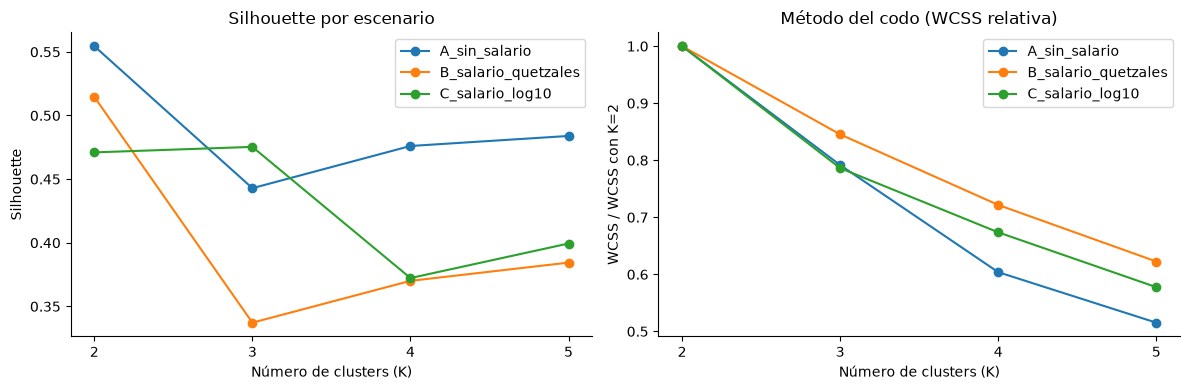

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for escenario, grupo in resultados_df.groupby('escenario'):
    axes[0].plot(grupo.k, grupo.silhouette, marker='o', label=escenario)
    axes[1].plot(grupo.k, grupo.wcss / grupo.wcss.iloc[0], marker='o', label=escenario)
axes[0].set(xlabel='Número de clusters (K)', ylabel='Silhouette', title='Silhouette por escenario', xticks=VALORES_K)
axes[1].set(xlabel='Número de clusters (K)', ylabel='WCSS / WCSS con K=2',
            title='Método del codo (WCSS relativa)', xticks=VALORES_K)
axes[0].legend()
axes[1].legend()
guardar_grafica('kmeans_silhouette_codo')

La WCSS se muestra relativa a K=2 porque cada escenario tiene distinto número de variables y sus valores absolutos no son comparables entre sí.

## 4.3 ¿Vale la pena incluir salario?

Se compara la silhouette de los tres escenarios para cada K y su promedio en K = 2–5.
El escenario con mayor silhouette promedio define las variables de la segmentación final.

In [5]:
pivote = resultados_df.pivot(index='k', columns='escenario', values='silhouette')
display(pivote.round(3))
promedio = pivote.mean().sort_values(ascending=False)
ESCENARIO = promedio.index[0]

escenario,A_sin_salario,B_salario_quetzales,C_salario_log10
k,,,
2,0.554,0.515,0.471
3,0.443,0.337,0.475
4,0.476,0.370,0.372
5,0.484,0.384,0.399


**Silhouette promedio en K = 2–5:** A_sin_salario: **0.489**; C_salario_log10: **0.430**; B_salario_quetzales: **0.402**. Sin salario, la silhouette supera al escenario con salario en quetzales en **4 de 4** valores de K y al escenario con log10 en **3 de 4**. Con salario en quetzales y K=5, el cluster más pequeño reúne sólo **4.0%** de los registros.

**Decisión: no se incluye salario para formar los grupos.** En quetzales, su cola larga agrega dispersión que KMeans no logra separar bien y reduce la silhouette. En log10 la cola se atenúa, pero los salarios muy bajos pasan a ser los extremos y la separación tampoco mejora de forma consistente. Además, dejar el salario fuera tiene una ventaja interpretativa: los clusters son **perfiles laborales** (edad, estabilidad y jornada) y después se puede comprobar si esos perfiles tienen salarios distintos sin haberlos forzado.

## 4.4 Elección de K

**Criterio del grupo**, aplicado dentro del escenario elegido:

1. K ≥ 3, porque el objetivo es describir **perfiles** de trabajadores y no sólo partir la muestra en dos.
2. Ningún cluster con menos del 5% de los registros, para evitar grupos de casos extremos.
3. Entre los K que cumplen, el de **mayor silhouette**. El método del codo se usa como apoyo.

In [6]:
del_escenario = resultados_df[resultados_df.escenario == ESCENARIO]
candidatos = del_escenario[(del_escenario.k >= K_MINIMO_PERFILES) &
                           (del_escenario.cluster_menor_pct >= TAMANIO_MINIMO_PCT)]
assert not candidatos.empty, 'Ningún K cumple el criterio; revisar umbrales.'
elegido = candidatos.sort_values('silhouette', ascending=False).iloc[0]
K = int(elegido.k)
mejor_global = del_escenario.sort_values('silhouette', ascending=False).iloc[0]

display(del_escenario[['k', 'silhouette', 'wcss', 'cluster_menor_pct', 'tamanios']].round(3))

if int(mejor_global.k) != K:
    modelo_global = modelos[(ESCENARIO, int(mejor_global.k))]
    perfil_global = (modelo_global.transform(base).groupBy('cluster')
        .agg(F.count('*').alias('n'),
             *[F.expr(f'percentile({v}, 0.5)').alias(f'{v}_mediana') for v in PERFIL])
        .orderBy('cluster').toPandas())
    display(perfil_global)

,k,silhouette,wcss,cluster_menor_pct,tamanios
0,2,0.554,106717.388,27.542,"38,421 / 14,604"
1,3,0.443,84468.146,13.535,"29,500 / 16,348 / 7,177"
2,4,0.476,64438.208,12.950,"24,488 / 12,742 / 8,928 / 6,867"
3,5,0.484,54990.353,11.653,"22,715 / 11,005 / 6,624 / 6,502 / 6,179"


,cluster,n,edad_mediana,antiguedad_mediana,horas_semanales_mediana
0,0,38421,28.0,1.333333,46.0
1,1,14604,51.0,13.000000,40.0


**K elegido: 5** (silhouette **0.484**, cluster más pequeño 11.7%).

K=2 tiene la silhouette más alta (0.554), pero la tabla anterior muestra que sólo separa trabajadores más jóvenes y con poca antigüedad de trabajadores mayores y con más antigüedad: la misma relación edad–antigüedad observada en la actividad 3. Con K=5 la silhouette sigue siendo moderada y aparecen perfiles que distinguen el tipo de jornada.

## 4.5 Perfil de cada cluster

Los centros se reportan en unidades estandarizadas (z): 0 es el promedio de 2025, +1 una desviación
por encima. Las medianas y percentiles se calculan en Spark con **todos** los registros de cada cluster.
El salario se usa aquí sólo para describir los grupos.

In [7]:
modelo_final = modelos[(ESCENARIO, K)]
segmentado = modelo_final.transform(base).drop('vector_original', 'features').cache()

centros = pd.DataFrame(modelo_final.stages[-1].clusterCenters(), columns=ESCENARIOS[ESCENARIO])
centros.index.name = 'cluster'

perfil = (segmentado.groupBy('cluster').agg(
        F.count('*').alias('n'),
        *[F.expr(f'percentile({v}, 0.5)').alias(f'{v}_mediana') for v in PERFIL],
        F.expr('percentile(salario_mensual, 0.25)').alias('salario_p25'),
        F.expr('percentile(salario_mensual, 0.5)').alias('salario_mediana'),
        F.expr('percentile(salario_mensual, 0.75)').alias('salario_p75'),
        F.mean('salario_mensual').alias('salario_media'))
    .orderBy('cluster').toPandas().set_index('cluster'))
perfil['porcentaje'] = 100 * perfil.n / n_total

def nivel(z):
    return 'alta' if z > UMBRAL_Z else 'baja' if z < -UMBRAL_Z else 'cercana al promedio'

def nombre_cluster(z):
    # Se nombra por el rasgo más distintivo, en orden de prioridad.
    if z['antiguedad'] > UMBRAL_Z:
        return 'Veteranos estables'
    if z['horas_semanales'] > UMBRAL_Z:
        return 'Jornada extensa'
    if z['horas_semanales'] < -UMBRAL_Z:
        return 'Jornada parcial'
    if z['edad'] > UMBRAL_Z:
        return 'Adultos con poca antigüedad'
    if z['edad'] < -UMBRAL_Z:
        return 'Jóvenes en inicio laboral'
    return 'Perfil intermedio'

NOMBRES = {}
for c in centros.index:
    nombre = nombre_cluster(centros.loc[c])
    NOMBRES[c] = nombre if nombre not in NOMBRES.values() else f'{nombre} ({c})'
perfil.insert(0, 'nombre', [NOMBRES[c] for c in perfil.index])

display(centros.rename(index=NOMBRES).round(2))
tabla(perfil.reset_index(), 'kmeans_perfil_clusters')

,edad,antiguedad,horas_semanales
cluster,,,
Veteranos estables,1.11,2.17,-0.27
Jornada extensa,-0.30,-0.24,1.85
Jornada parcial,-0.40,-0.34,-1.44
Adultos con poca antigüedad,1.09,-0.18,-0.16
Jóvenes en inicio laboral,-0.66,-0.38,0.07


,cluster,nombre,n,edad_mediana,antiguedad_mediana,horas_semanales_mediana,salario_p25,salario_mediana,salario_p75,salario_media,porcentaje
0,0,Veteranos estables,6624,49.0,20.000000,40.0,2300.0,3800.0,6000.0,4716.498339,12.492221
1,1,Jornada extensa,6179,30.0,2.000000,76.0,2000.0,3000.0,3907.0,3266.902250,11.652994
2,2,Jornada parcial,6502,30.0,1.166667,21.0,600.0,1200.0,2600.0,1943.866195,12.262140
3,3,Adultos con poca antigüedad,11005,48.0,3.000000,44.0,1800.0,3200.0,4000.0,3707.102317,20.754361
4,4,Jóvenes en inicio laboral,22715,26.0,1.500000,48.0,2000.0,3200.0,4000.0,3370.937794,42.838284


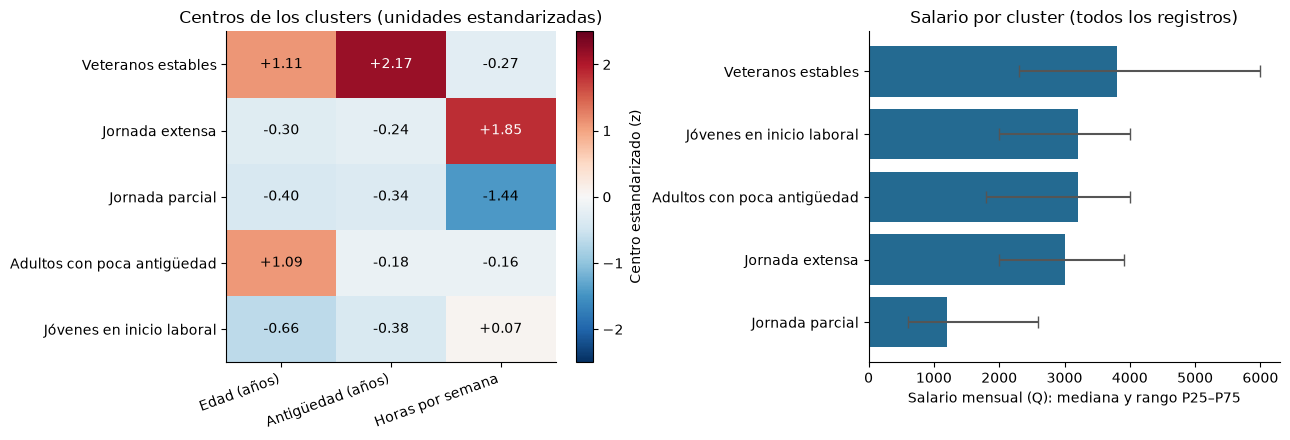

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
matriz = centros.rename(index=NOMBRES)
img = axes[0].imshow(matriz.values, cmap='RdBu_r', vmin=-2.5, vmax=2.5, aspect='auto')
axes[0].set_xticks(range(matriz.shape[1]), [ETIQUETAS[v] for v in matriz.columns], rotation=20, ha='right')
axes[0].set_yticks(range(matriz.shape[0]), matriz.index)
for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        axes[0].text(j, i, f'{matriz.values[i, j]:+.2f}', ha='center', va='center',
                     color='white' if abs(matriz.values[i, j]) > 1.5 else 'black')
fig.colorbar(img, ax=axes[0], label='Centro estandarizado (z)')
axes[0].set_title('Centros de los clusters (unidades estandarizadas)')

orden = perfil.sort_values('salario_mediana')
axes[1].barh(orden.nombre, orden.salario_mediana, color='#246a91',
             xerr=[orden.salario_mediana - orden.salario_p25, orden.salario_p75 - orden.salario_mediana],
             capsize=4, ecolor='#555555')
axes[1].set(xlabel='Salario mensual (Q): mediana y rango P25–P75', title='Salario por cluster (todos los registros)')
guardar_grafica('kmeans_centros_salario')

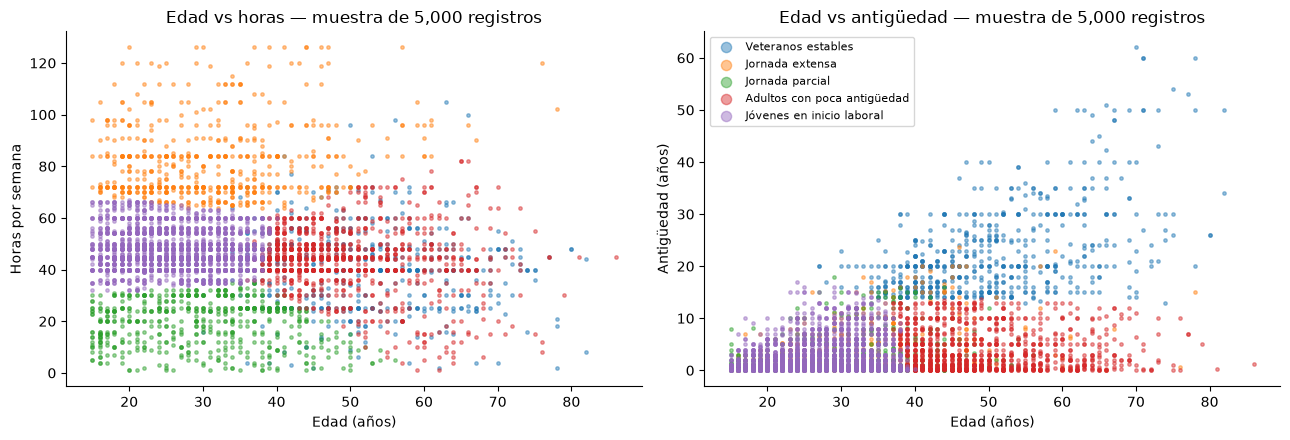

In [9]:
# La muestra sólo se usa para dibujar; los perfiles y métricas usan todos los registros.
muestra = (segmentado.sample(fraction=min(1.0, 6000 / n_total), seed=SEMILLA)
           .limit(5000).select(*PERFIL, 'cluster').toPandas())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for c, grupo in muestra.groupby('cluster'):
    axes[0].scatter(grupo.edad, grupo.horas_semanales, s=6, alpha=0.45, label=NOMBRES[c])
    axes[1].scatter(grupo.edad, grupo.antiguedad, s=6, alpha=0.45, label=NOMBRES[c])
axes[0].set(xlabel='Edad (años)', ylabel='Horas por semana', title=f'Edad vs horas — muestra de {len(muestra):,} registros')
axes[1].set(xlabel='Edad (años)', ylabel='Antigüedad (años)', title=f'Edad vs antigüedad — muestra de {len(muestra):,} registros')
axes[1].legend(markerscale=3, fontsize=8, loc='upper left')
guardar_grafica('kmeans_dispersion_muestra')

### Composición por variables categóricas

Porcentaje de cada categoría **dentro** de cada cluster (cada fila suma 100%). Las categóricas no
participaron en la formación de los grupos; aquí sirven para describirlos.

**Nivel educativo**

nivel_educativo,cluster,NINGUNO,PREPRIMARIA,PRIMARIA,BÁSICO,DIVERSIFICADO,SUPERIOR,MAESTRÍA,DOCTORADO
0,Veteranos estables,13.1,1.2,27.6,8.2,25.3,21.6,2.5,0.5
1,Jornada extensa,4.9,0.9,34.7,21.2,33.2,4.7,0.4,0.0
2,Jornada parcial,8.5,1.0,32.0,17.0,26.1,14.8,0.7,0.0
3,Adultos con poca antigüedad,14.0,1.3,36.9,10.9,21.6,12.6,2.6,0.2
4,Jóvenes en inicio laboral,3.3,0.6,25.1,18.0,39.9,12.1,1.1,0.0


**Categoria ocupacional**

categoria_ocupacional,cluster,Empleado de gobierno,Empleado de empresa privada,Empleado jornalero o peón,Del servicio doméstico
0,Veteranos estables,31.5,40.4,22.2,5.9
1,Jornada extensa,9.5,67.0,17.9,5.6
2,Jornada parcial,14.7,28.1,40.0,17.3
3,Adultos con poca antigüedad,12.9,50.7,26.4,10.0
4,Jóvenes en inicio laboral,6.7,63.8,25.3,4.1


**Dominio**

dominio,cluster,Urbano Metropolitano,Resto Urbano,Rural Nacional
0,Veteranos estables,44.6,38.9,16.5
1,Jornada extensa,31.9,45.1,23.1
2,Jornada parcial,28.0,44.0,28.0
3,Adultos con poca antigüedad,49.2,33.8,17.0
4,Jóvenes en inicio laboral,43.6,36.1,20.2


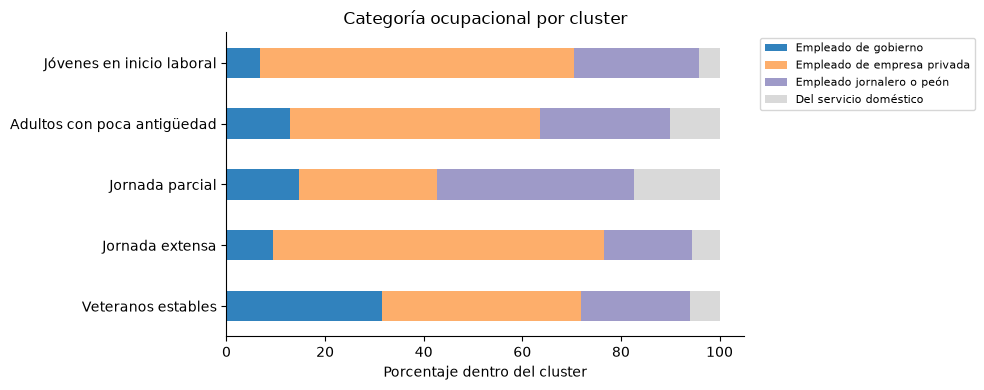

In [10]:
def etiquetas_diccionario(variable):
    # Etiquetas del diccionario guardadas por el notebook 01.
    ruta = OUT / f'distribucion_{variable}_2025.csv'
    if not ruta.exists():
        return {}
    d = pd.read_csv(ruta, dtype={variable: str})
    return dict(zip(d[variable], d.etiqueta.str.strip().str.rstrip('?').str.strip()))

composicion = {}
for variable in CATEGORICAS:
    conteo = segmentado.groupBy('cluster', variable).count().toPandas()
    pct = conteo.pivot(index='cluster', columns=variable, values='count').fillna(0)
    pct = 100 * pct.div(pct.sum(axis=1), axis=0)
    composicion[variable] = pct
    vista = pct.rename(columns=etiquetas_diccionario(variable)).rename(index=NOMBRES).round(1)
    explicar(f'**{variable.replace("_", " ").capitalize()}**')
    tabla(vista.reset_index(names='cluster'), f'kmeans_composicion_{variable}')

vista = composicion['categoria_ocupacional'].rename(
    columns=etiquetas_diccionario('categoria_ocupacional')).rename(index=NOMBRES)
vista.plot(kind='barh', stacked=True, figsize=(10, 4), colormap='tab20c')
plt.xlabel('Porcentaje dentro del cluster')
plt.ylabel('')
plt.title('Categoría ocupacional por cluster')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
guardar_grafica('kmeans_categoria_ocupacional')

## 4.6 Descripción de cada cluster

In [11]:
etiquetas_categoria = etiquetas_diccionario('categoria_ocupacional')
descripciones = []
for c in perfil.index:
    p, z = perfil.loc[c], centros.loc[c]
    categoria = composicion['categoria_ocupacional'].loc[c]
    principal = categoria.idxmax()
    educacion = composicion['nivel_educativo'].loc[c]
    superior = educacion[[x for x in ['5', '6', '7'] if x in educacion.index]].sum()
    rural = composicion['dominio'].loc[c].get('3', 0.0)
    texto = (f"**Cluster {c} — {NOMBRES[c]}** ({int(p.n):,} registros, {p.porcentaje:.1f}%): "
             f"edad mediana {p.edad_mediana:.0f} años ({nivel(z['edad'])}), antigüedad mediana "
             f"{p.antiguedad_mediana:.1f} años ({nivel(z['antiguedad'])}) y {p.horas_semanales_mediana:.0f} horas "
             f"semanales ({nivel(z['horas_semanales'])}). Salario mediano **Q{p.salario_mediana:,.0f}** "
             f"(P25–P75: Q{p.salario_p25:,.0f}–Q{p.salario_p75:,.0f}). Categoría más frecuente: "
             f"{etiquetas_categoria.get(principal, principal)} ({categoria.max():.1f}%); "
             f"{superior:.1f}% con educación superior o posgrado y {rural:.1f}% en el dominio rural.")
    descripciones.append({'cluster': c, 'nombre': NOMBRES[c], 'descripcion': texto.replace('**', '')})
pd.DataFrame(descripciones).to_csv(OUT / 'kmeans_descripcion_clusters.csv', index=False)

**Cluster 0 — Veteranos estables** (6,624 registros, 12.5%): edad mediana 49 años (alta), antigüedad mediana 20.0 años (alta) y 40 horas semanales (cercana al promedio). Salario mediano **Q3,800** (P25–P75: Q2,300–Q6,000). Categoría más frecuente: Empleado de empresa privada (40.4%); 24.7% con educación superior o posgrado y 16.5% en el dominio rural.

**Cluster 1 — Jornada extensa** (6,179 registros, 11.7%): edad mediana 30 años (cercana al promedio), antigüedad mediana 2.0 años (cercana al promedio) y 76 horas semanales (alta). Salario mediano **Q3,000** (P25–P75: Q2,000–Q3,907). Categoría más frecuente: Empleado de empresa privada (67.0%); 5.1% con educación superior o posgrado y 23.1% en el dominio rural.

**Cluster 2 — Jornada parcial** (6,502 registros, 12.3%): edad mediana 30 años (cercana al promedio), antigüedad mediana 1.2 años (cercana al promedio) y 21 horas semanales (baja). Salario mediano **Q1,200** (P25–P75: Q600–Q2,600). Categoría más frecuente: Empleado jornalero o peón (40.0%); 15.5% con educación superior o posgrado y 28.0% en el dominio rural.

**Cluster 3 — Adultos con poca antigüedad** (11,005 registros, 20.8%): edad mediana 48 años (alta), antigüedad mediana 3.0 años (cercana al promedio) y 44 horas semanales (cercana al promedio). Salario mediano **Q3,200** (P25–P75: Q1,800–Q4,000). Categoría más frecuente: Empleado de empresa privada (50.7%); 15.4% con educación superior o posgrado y 17.0% en el dominio rural.

**Cluster 4 — Jóvenes en inicio laboral** (22,715 registros, 42.8%): edad mediana 26 años (baja), antigüedad mediana 1.5 años (cercana al promedio) y 48 horas semanales (cercana al promedio). Salario mediano **Q3,200** (P25–P75: Q2,000–Q4,000). Categoría más frecuente: Empleado de empresa privada (63.8%); 13.2% con educación superior o posgrado y 20.2% en el dominio rural.

**Síntesis.** La segmentación final usa **edad, antiguedad, horas_semanales** con **K=5** (silhouette 0.484). Una silhouette de ese orden indica grupos distinguibles pero con traslape: los perfiles laborales forman un continuo y los clusters son una simplificación útil, no tipos cerrados. Aunque el salario no se usó para formarlos, el salario mediano va de **Q1,200** en *Jornada parcial* a **Q3,800** en *Veteranos estables* (3.2 veces). Esto indica que la jornada y la estabilidad laboral se asocian con el salario, aunque la segmentación es descriptiva y no establece causalidad. Los grupos describen los registros analizados de 2025, sin ponderar por FACTOR.

In [12]:
ruta_modelo = MODELOS / 'kmeans_segmentacion'
modelo_final.write().overwrite().save(str(ruta_modelo))

mapa_nombres = F.create_map(*[x for c, n in NOMBRES.items() for x in (F.lit(int(c)), F.lit(n))])
(segmentado.select('periodo_archivo', 'NUM_HOGAR', 'NUM_PERSONA', 'cluster',
                   mapa_nombres[F.col('cluster')].alias('nombre_cluster'))
    .write.mode('overwrite').parquet(str(OUT / 'segmentacion_kmeans_2025')))

seleccion = {
    'escenario': ESCENARIO, 'variables': ESCENARIOS[ESCENARIO], 'k': K,
    'silhouette': float(elegido.silhouette), 'semilla': SEMILLA,
    'criterio': f'K >= {K_MINIMO_PERFILES}, cluster menor >= {TAMANIO_MINIMO_PCT}%, mayor silhouette',
    'nombres': {str(c): n for c, n in NOMBRES.items()},
}
(OUT / 'seleccion_kmeans.json').write_text(json.dumps(seleccion, indent=2, ensure_ascii=False), encoding='utf-8')

segmentado.unpersist()
base.unpersist()
print('Segmentación terminada. Modelo guardado en:', ruta_modelo)

Segmentación terminada. Modelo guardado en: /opt/app/laboratorio/Transform_Data/modelos/kmeans_segmentacion


## Notas metodológicas

- El `Pipeline` completo (ensamblado, estandarización y KMeans) se guarda en `Transform_Data/modelos/kmeans_segmentacion`.
- La asignación de cada registro de 2025 a su cluster se guarda en `Transform_Data/segmentacion_kmeans_2025`,
  sólo para análisis descriptivo. **El cluster no se utiliza como predictor** en los modelos supervisados.
- Los nombres de los clusters se asignan con reglas explícitas sobre los centros estandarizados
  (|z| > 0.5), por lo que se regeneran de forma reproducible a partir de los resultados.